In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter

from scipy import integrate
import json

import matplotlib.pyplot as plt


In [2]:
cwd=Path.cwd()

In [3]:
def smoothing(csv_path, time_step=1.0):
    df = pd.read_csv(csv_path)
    target_time = np.arange(df['Zeit [s]'].min(), df['Zeit [s]'].max(), time_step)
    resampled_df = pd.DataFrame({'Zeit [s]': target_time})
    

    for col in df.columns.drop('Zeit [s]'):
        resampled_df[col] = np.interp(target_time, df['Zeit [s]'], df[col])
        

    for col in resampled_df.columns.drop('Zeit [s]'):
        resampled_df[col] = resampled_df[col].rolling(window=11, center=True, min_periods=1).mean()
        
    return resampled_df

def smoothing1(csv_path, time_step=1.0):
    df = pd.read_csv(csv_path)
    
    target_time = np.arange(df['Zeit [s]'].min(), df['Zeit [s]'].max(), time_step)
    resampled_df = pd.DataFrame({'Zeit [s]': target_time})
    
    columns=df.columns.tolist()
    
    for col in columns:

        smoothed_data = savgol_filter(df[col], window_length=21, polyorder=2)
        

        resampled_df[col] = np.interp(target_time, df['Zeit [s]'], smoothed_data)
        
    return resampled_df

In [ ]:
archive= cwd/'STIMTEC_example/BH10_20180718_40.6_SR.csv'

datar= smoothing(archive)


In [ ]:
# export=datar.copy()
# export.rename(columns={'Pint_downhole [MPa]':'Pint_downhole [MPa]_s'}, inplace=True)
# export.to_csv(cwd/'STIMTEC_example/BH10_20180718_40.6_SR_v2.csv', index=False)

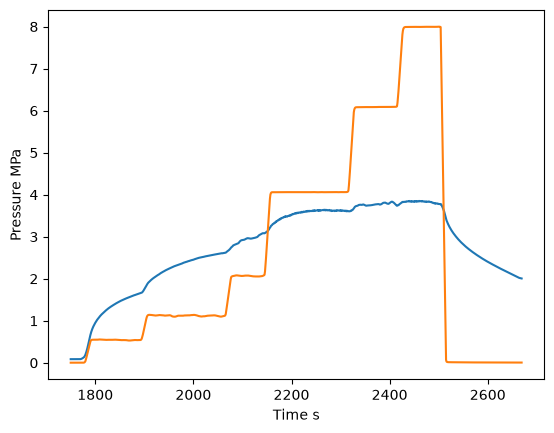

In [6]:
plt.plot(datar['Zeit [s]'],datar['Pint_downhole [MPa]'])
plt.plot(datar['Zeit [s]'],datar['Q_downhole [lpm]_s'])
plt.ylabel("Pressure MPa")
plt.xlabel("Time s")
plt.pause(1)

In [7]:
p = np.array(datar['Pint_downhole [MPa]'])
t = np.array(datar['Zeit [s]'])

P_sum_c = integrate.simpson(y=p, x=t) if len(p) > 1 else 0.0
#pref=integrate.trapezoid(y=p, x=t) if len(p) > 1 else 0.0
P_sum_c=P_sum_c*1e6
P_peak = np.max(p)*1e6
P_p_end = p[-1]*1e6

print(P_sum_c,"\n",P_peak,"\n", P_p_end)

2518265575.9051256 
 3852838.4545454546 
 2006926.4999999995


# Comparison models

In [8]:
def load_jdata(jsonl_file):
    with open(jsonl_file, 'r') as f:
        data = [json.loads(line) for line in f]
    return data

def get_metric_array(data, metric_key):
    data.sort(key=lambda x: x['index'])
    return np.array([item[metric_key] for item in data])

def diff_reor(df,key,variable):
    
    diff=np.abs(df[key]-variable)
    sorted_diff = diff.sort_values(ascending=True)

    return sorted_diff.index #return clean indexes for masking

1. Load the json files
2. Format the new variable in order to analyse (flatten all into one long table)
3. Compare and clasify: three tops and last with this criteria: (a). area (b). peak (c). tail (orderly)
4. Load npy files and format them 
5. Find ids of the runs of the three (per category) and graph them.
6. Visualise inspect and them extract the 'aparent' optimised factors.

In [9]:
#1 and 2
version_list=[#'v1','v2','v3','v4','v5','v6','v7','v8',
               # 'v9',
              'v10','v11','v12'
             ]
results=[]
bases=[]
n_r=[] #runs per N parameter
counter=1

for version in version_list:

    json_file= cwd/f'results_{version}/results/results_archive_{version}.jsonl'
    sample_archive= cwd/f'results_{version}/morris_samples_{version}.csv'


    Y = load_jdata(json_file)
    X = pd.read_csv(sample_archive,header=0)
    run=counter
    runs=[run for i in range(len(X))]
    n_r=pd.DataFrame(runs, columns=['run'])

    metrics = ['index','sum_c', 'peak', 'p_end']

    result = {}
    for m in metrics:
        Ym = get_metric_array(Y, m)
        result[m] = Ym

    counter+=1
    convert=pd.DataFrame.from_dict(result)
    convert=pd.concat([n_r,convert],axis=1)
    results.append(convert)
    bases.append(X)
flat=pd.concat(results,axis=0,ignore_index=True)


In [73]:
sum_index=diff_reor(flat,metrics[1],P_sum_c)
peak_index=diff_reor(flat,metrics[2],P_peak)
pend_index=diff_reor(flat,metrics[3],P_p_end)

In [74]:
search_sum=[flat.loc[sum_index[:3],'run':'index']]
search_peak=[flat.loc[peak_index[:3],'run':'index']]
search_pend=[flat.loc[pend_index[:3],'run':'index']]

In [75]:
print(search_sum,'\n',search_peak,'\n',search_pend)

[     run  index
126    3     66
94     3     34
19     2      9] 
 [     run  index
109    3     49
84     3     24
7      1      7] 
 [     run  index
165    3    105
140    3     80
146    3     86]


In [9]:
mask = flat["peak"] >= P_peak
# l_peaks = flat.loc[mask, "run":"index"]
l_peaks = flat.loc[mask, :]

sampled_df = l_peaks.sample(n=5, replace=False)

testing_ = sampled_df.to_numpy()



In [ ]:
v7r8_raw=np.load(cwd/"results_v7/results/raw_data/raw_run_8.npy",allow_pickle=True)
v7r8= v7r8_raw.item()

v9r65_raw=np.load(cwd/"results_v9/results/raw_data/raw_run_65.npy",allow_pickle=True)
v9r65= v9r65_raw.item()

In [18]:
raw_paths = list((cwd / "results_v9/results/raw_data").glob("*.npy"))

file_paths = sorted(
    raw_paths, 
    key=lambda p: int(p.stem.split('_')[2])  
)

vr_list = [np.load(file, allow_pickle=True).item() for file in file_paths]

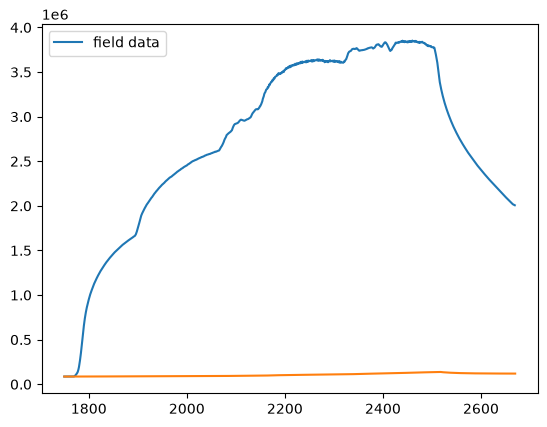

In [20]:
plt.plot(datar['Zeit [s]'],datar['Pint_downhole [MPa]']*1e6,label='field data')
#plt.plot(datar['Zeit [s]'],datar['Q_downhole [lpm]_s']*1e6)
# for i in range(len(vr_list)):

#     plt.plot(vr_list[i]['timevalues'], vr_list[i]['values'],ls='--' #,label=f"curve {i}"
#              )

plt.plot(vr_list[65]['timevalues'], vr_list[65]['values'])
# plt.plot(vr_list[34]['timevalues'], vr_list[34]['values'])
# plt.plot(vr_list[66]['timevalues'], vr_list[66]['values'])
# plt.plot(vr_list[49]['timevalues'], vr_list[49]['values'])
# plt.plot(vr_list[24]['timevalues'], vr_list[24]['values'])
# plt.plot(vr_list[105]['timevalues'], vr_list[105]['values'])
# plt.plot(vr_list[80]['timevalues'], vr_list[80]['values'])
# plt.plot(vr_list[86]['timevalues'], vr_list[86]['values'])
# plt.plot(v7r8['timevalues'], v7r8['values'])
# plt.plot(v9r65['timevalues'], v9r65['values'])
plt.legend()

plt.pause(1)

# Setting heat map of current Morris Analyses:

In [3]:
from objective_function import objective_function
import seaborn as sns

In [4]:
field_data_path=cwd/'STIMTEC_example/BH10_20180718_40.6_SR_v2.csv'
field_data= pd.read_csv(field_data_path,header=0)

version="v12" #plain as not iteration list
morris_path= cwd/f'results_{version}/morris_samples_{version}.csv'
morris_df= pd.read_csv(morris_path,header=0) 


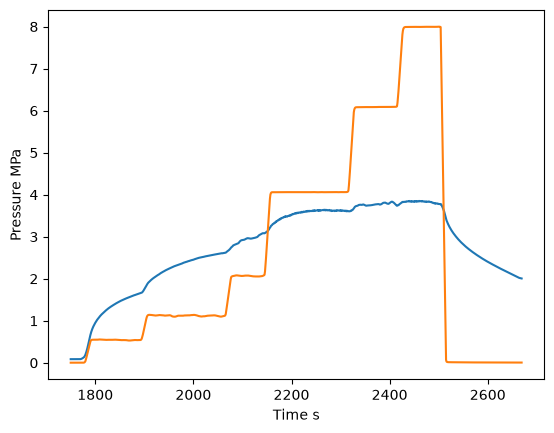

In [ ]:
plt.plot(field_data['Zeit [s]'],field_data['Pint_downhole [MPa]_s'])
plt.plot(field_data['Zeit [s]'],field_data['Q_downhole [lpm]_s'])
plt.ylabel("Pressure / MPa")
plt.xlabel("Time / s")
plt.pause(1)

In [5]:
raw_paths = list((cwd / "results_v12/results/raw_data").glob("*.npy"))

file_paths = sorted(
    raw_paths, 
    key=lambda p: int(p.stem.split('_')[2])  
)

vr_list = [np.load(file, allow_pickle=True).item() for file in file_paths]

In [6]:
rmse_c=[]
for value in vr_list:
    rmse=objective_function(value,field_data)
    rmse_c.append(rmse)
rmse_c=np.array(rmse_c)

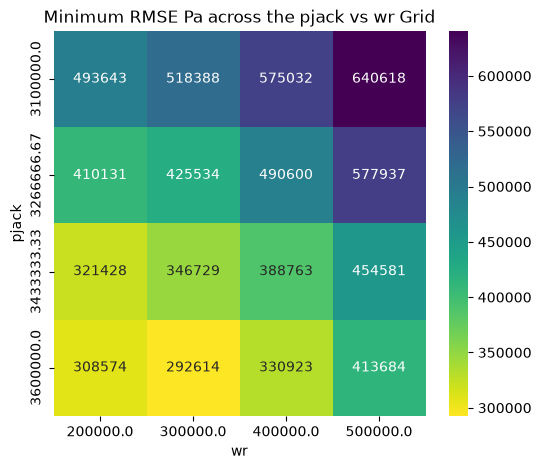

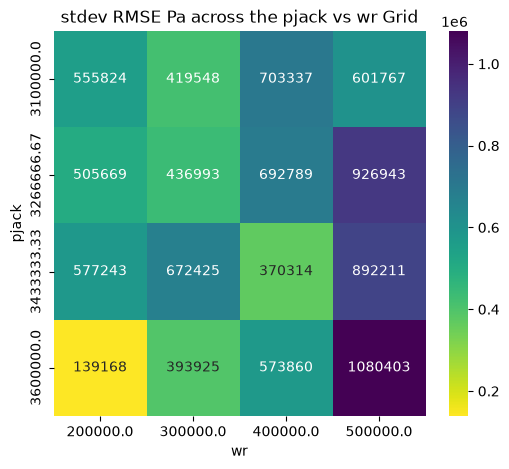

In [9]:
#NOTE: Guaranteeing not crash NaN runds within npy files imported 
morris_df["RMSE"]=rmse_c

pivot_table = morris_df.groupby(['pjack', 'wr'])['RMSE'].min().unstack()
pivot_table.index = pivot_table.index.round(2)
pivot_table.columns = pivot_table.columns.round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="viridis_r")
plt.title("Minimum RMSE Pa across the pjack vs wr Grid")
plt.show()

std_table = morris_df.groupby(['pjack', 'wr'])['RMSE'].std().unstack()
std_table.index = std_table.index.round(2)
std_table.columns = std_table.columns.round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(std_table, annot=True, fmt=".0f", cmap="viridis_r")
plt.title("stdev RMSE Pa across the pjack vs wr Grid")
plt.show()